Random Cut Forest (RCF) Model

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [3]:
train_data = pd.read_csv('/content/drive/MyDrive/dataset/labelled_training_data.csv')
val_data = pd.read_csv('/content/drive/MyDrive/dataset/labelled_validation_data.csv')
test_data = pd.read_csv('/content/drive/MyDrive/dataset/labelled_testing_data.csv')

In [4]:
train_data.head(2)

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,1809.495787,381,7337,1,100,4026532231,close,ip-10-100-1-120,157,prctl,"[140662171848350, 11649800180280676]",5,0,"[{'name': 'option', 'type': 'int', 'value': 'P...",1,0
1,1809.495832,381,7337,1,100,4026532231,close,ip-10-100-1-120,3,close,[140662171777451],1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]",1,0


In [5]:
train_data.describe(include=['object', 'float', 'int'])

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
count,763144.000000,763144.000000,763144.000000,763144.000000,763144.000000,7.631440e+05,763144,763144,763144.000000,763144,763144,763144.000000,763144.000000,763144,763144.000000,763144.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,36,8,NaN,32,97050,NaN,NaN,214720,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,ps,ubuntu,NaN,close,[],NaN,NaN,"[{'name': 'fd', 'type': 'int', 'value': 9}]",NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,406313,190500,NaN,218080,521115,NaN,NaN,107321,NaN,NaN
mean,1844.582673,6814.763308,6820.265241,1882.216609,2.279034,4.026532e+09,NaN,NaN,288.158953,NaN,NaN,2.672082,17.520924,NaN,0.001663,0.0
std,1136.638249,1948.871187,1937.068333,2215.563094,37.416576,1.649030e+02,NaN,NaN,385.117778,NaN,NaN,1.340906,318.596662,NaN,0.040744,0.0
min,132.560721,1.000000,1.000000,0.000000,0.000000,4.026532e+09,NaN,NaN,3.000000,NaN,NaN,0.000000,-115.000000,NaN,0.000000,0.0
25%,903.250802,7313.000000,7313.000000,187.000000,0.000000,4.026532e+09,NaN,NaN,3.000000,NaN,NaN,1.000000,0.000000,NaN,0.000000,0.0
50%,1829.203642,7365.000000,7365.000000,1385.000000,0.000000,4.026532e+09,NaN,NaN,62.000000,NaN,NaN,3.000000,0.000000,NaN,0.000000,0.0
75%,2761.380825,7415.000000,7415.000000,1648.000000,0.000000,4.026532e+09,NaN,NaN,257.000000,NaN,NaN,4.000000,4.000000,NaN,0.000000,0.0


In [6]:
#encoding processname and eventname

from sklearn.preprocessing import LabelEncoder

def label_encode_replace_columns(data, columns):
    label_encoder = LabelEncoder()
    for column in columns:
        encoded_column = label_encoder.fit_transform(data[column])
        data[column] = encoded_column
    return data


# Assuming 'train_data' is your dataset and ['processName', 'eventName'] are the columns you want to encode
train_data_encoded = label_encode_replace_columns(train_data, ['processName', 'eventName'])
test_data_encoded = label_encode_replace_columns(val_data, ['processName', 'eventName'])
val_data_encoded = label_encode_replace_columns(test_data, ['processName', 'eventName'])

In [7]:
unique_process_names = train_data['processName'].unique()
print(unique_process_names)


[ 6 23 22  5 29 27 28  9  2 35 10 31 11  7  4 21  8 24 30 14 15 26 19 12
 13  3 33 17 20  1 16 18 32 34  0 25]


In [8]:
unique_process_names = train_data['eventName'].unique()
print(unique_process_names)

[19  6 20  2 22 18 13 27  5 11 21 14  4 16 17 12 23 30 10 26  7  9  1 31
 29 15 28  3 24 25  0  8]


In [9]:
train_data.head(2)

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,1809.495787,381,7337,1,100,4026532231,6,ip-10-100-1-120,157,19,"[140662171848350, 11649800180280676]",5,0,"[{'name': 'option', 'type': 'int', 'value': 'P...",1,0
1,1809.495832,381,7337,1,100,4026532231,6,ip-10-100-1-120,3,6,[140662171777451],1,0,"[{'name': 'fd', 'type': 'int', 'value': 19}]",1,0


In [10]:
val_data.head(2)

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,124.439221,381,381,1,101,4026532232,28,ip-10-100-1-129,41,24,"[139913106282763, 139913103116537, 94901962555...",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0
1,124.439751,378,378,1,100,4026532231,27,ip-10-100-1-129,41,24,"[140343254628619, 93967981149065, 93967990898192]",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0


In [11]:
test_data.head(2)

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
0,129.050634,382,382,1,101,4026532232,78,ip-10-100-1-217,41,40,"[140159195621643, 140159192455417, 94656731598...",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0
1,129.051238,379,379,1,100,4026532231,77,ip-10-100-1-217,41,40,"[139853228042507, 93935071185801, 93935080775184]",3,15,"[{'name': 'domain', 'type': 'int', 'value': 'A...",0,0


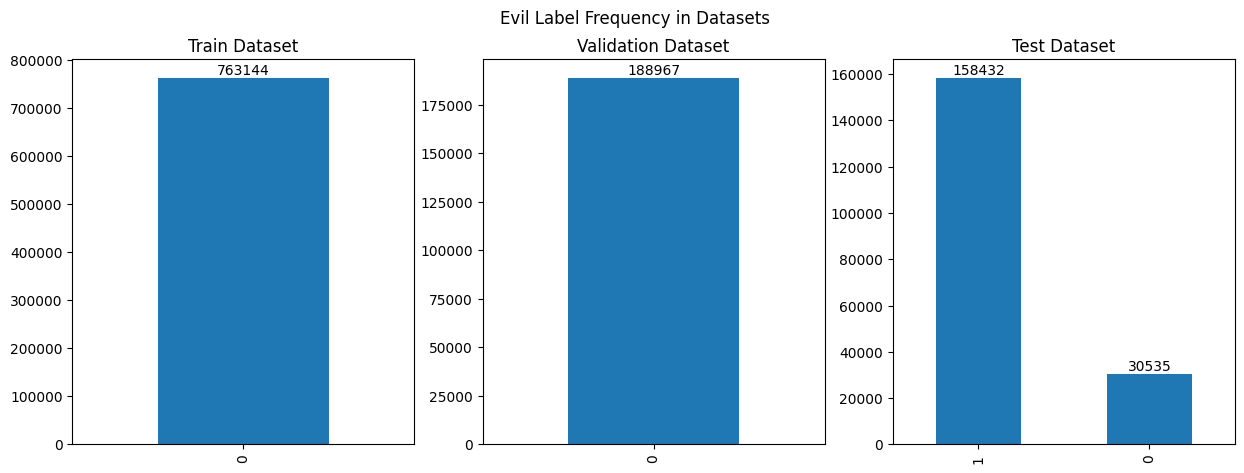

In [12]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Plot for train_data
train_counts = train_data.evil.value_counts()
train_counts.plot(kind='bar', title='Train Dataset', ax=axes[0])
for i, count in enumerate(train_counts):
    axes[0].text(i, count, str(count), ha='center', va='bottom')

# Plot for val_data
val_counts = val_data.evil.value_counts()
val_counts.plot(kind='bar', title='Validation Dataset', ax=axes[1])
for i, count in enumerate(val_counts):
    axes[1].text(i, count, str(count), ha='center', va='bottom')

# Plot for test_data
test_counts = test_data.evil.value_counts()
test_counts.plot(kind='bar', title='Test Dataset', ax=axes[2])
for i, count in enumerate(test_counts):
    axes[2].text(i, count, str(count), ha='center', va='bottom')

# Set overall title
plt.suptitle('Evil Label Frequency in Datasets')

# Show plots
plt.show()


<ipython-input-13-1186a8382999>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = dataframe.corr()


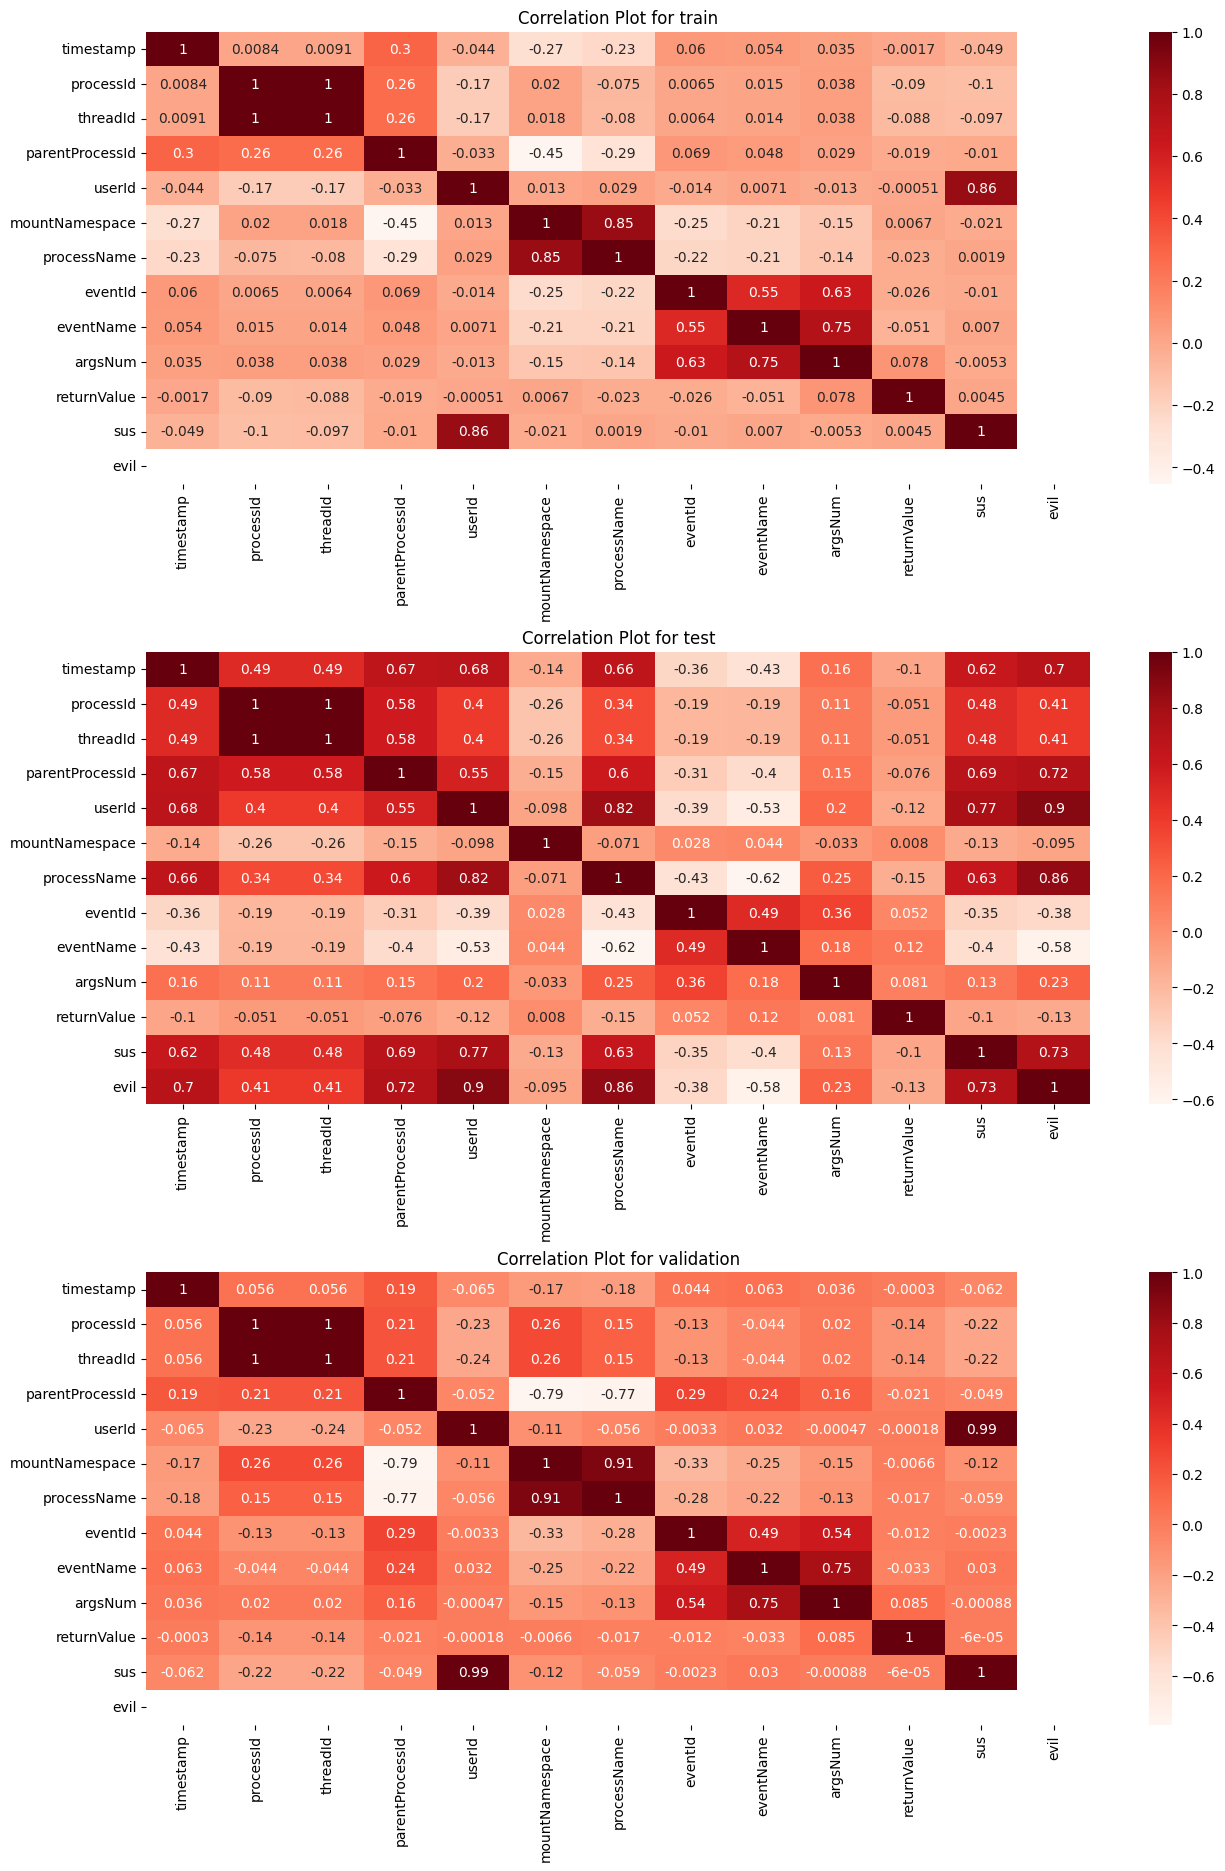

In [13]:
import seaborn as sns

def dataset_to_corr_heatmap(dataframe, title, ax):
    corr = dataframe.corr()
    sns.heatmap(corr, ax = ax, annot=True, cmap="Reds")
    ax.set_title(f'Correlation Plot for {title}')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (15,20))
fig.tight_layout(pad=10.0)
datasets = [train_data, test_data, val_data]
dataset_names = ['train', 'test', 'validation']
axs = [ax1, ax2, ax3]

for dataset, name, ax in zip(datasets, dataset_names, axs):
    dataset_to_corr_heatmap(dataset, name, ax)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

class RandomForestModel:
    def __init__(self, path):
        data = pd.read_csv(path)

        # Remove the problematic row (275968) before preprocessing
        data = data.drop(index=275968, errors='ignore')

        # Preprocessing
        labels = pd.DataFrame(data[["sus", "evil"]])
        data = pd.DataFrame(data[["processId", "parentProcessId", "userId", "mountNamespace", "processName", "eventId", "eventName", "argsNum", "returnValue"]])

        # Map features
        data["processId"] = data["processId"].map(lambda x: 0 if x in [0, 1, 2] else 1)
        data["parentProcessId"] = data["parentProcessId"].map(lambda x: 0 if x in [0, 1, 2] else 1)
        data["userId"] = data["userId"].map(lambda x: 0 if x < 1000 else 1)
        data["mountNamespace"] = data["mountNamespace"].map(lambda x: 0 if x == 4026531840 else 1)
        data["returnValue"] = data["returnValue"].map(lambda x: 0 if x == 0 else (1 if x > 0 else 2))

        # Apply label encoding
        columns_to_encode = ["processName", "eventName"]
        data = self.label_encode_replace_columns(data, columns_to_encode)

        # Set column names after label encoding
        data.columns = ["processId", "parentProcessId", "userId", "mountNamespace", "processName", "eventId", "eventName", "argsNum", "returnValue"]

        self.X = data
        self.y = labels["evil"]

        # Initialize Random Forest Classifier
        self.model = RandomForestClassifier()

    def label_encode_replace_columns(self, data, columns):
        label_encoders = {}
        for col in columns:
            label_encoders[col] = LabelEncoder()
            data[col] = label_encoders[col].fit_transform(data[col])
        return data

    def train(self):
        self.model.fit(self.X, self.y)

    def predict(self, X_test):
        return self.model.predict(X_test)




In [16]:
# instance of training
train_dataset = RandomForestModel('/content/drive/MyDrive/dataset/labelled_training_data.csv')

# instance of validation
val_dataset = RandomForestModel('/content/drive/MyDrive/dataset/labelled_validation_data.csv')

# instance of test
test_dataset = RandomForestModel('/content/drive/MyDrive/dataset/labelled_testing_data.csv')

# Print X and y for training dataset
print("Training Dataset:")
print("X:")
print(train_dataset.X.head(1))
print("\ny:")
print(train_dataset.y.head(1))
print("-----------------------------------")
# Print X and y for validation dataset
print("\nValidation Dataset:")
print("X:")
print(val_dataset.X.head(1))
print("\ny:")
print(val_dataset.y.head(1))
print("-----------------------------------")
# Print X and y for test dataset
print("\ntest Dataset:")
print("X:")
print(test_dataset.X.head(1))
print("\ny:")
print(test_dataset.y.head(1))

Training Dataset:
X:
   processId  parentProcessId  userId  mountNamespace  processName  eventId  \
0          1                0       0               1            6      157   

   eventName  argsNum  returnValue  
0         19        5            0  

y:
0    0
Name: evil, dtype: int64
-----------------------------------

Validation Dataset:
X:
   processId  parentProcessId  userId  mountNamespace  processName  eventId  \
0          1                0       0               1           28       41   

   eventName  argsNum  returnValue  
0         24        3            1  

y:
0    0
Name: evil, dtype: int64
-----------------------------------

test Dataset:
X:
   processId  parentProcessId  userId  mountNamespace  processName  eventId  \
0          1                0       0               1           78       41   

   eventName  argsNum  returnValue  
0         40        3            1  

y:
0    0
Name: evil, dtype: int64



Shapes before train-test split:
X_train: (763143, 9)
y_train: (763143,)
X_val: (188967, 9)
y_val: (188967,)

Validation Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    188967

    accuracy                           1.00    188967
   macro avg       1.00      1.00      1.00    188967
weighted avg       1.00      1.00      1.00    188967



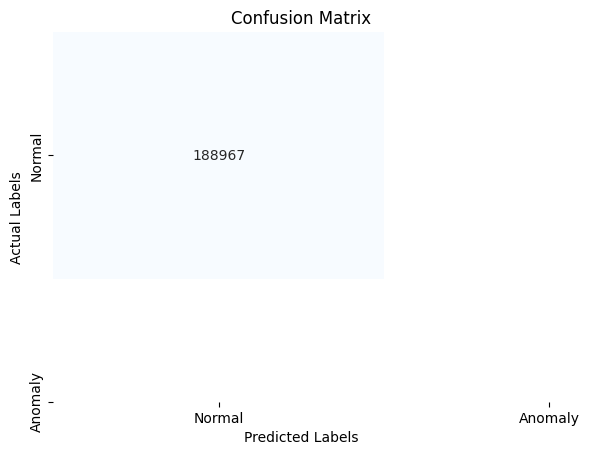

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def train_validate_random_forest(train_dataset, val_dataset):
    # Print the shapes of X and y to check for consistency
    print("\nShapes before train-test split:")
    print("X_train:", train_dataset.X.shape)
    print("y_train:", train_dataset.y.shape)
    print("X_val:", val_dataset.X.shape)
    print("y_val:", val_dataset.y.shape)

    # Create and train the Random Forest Classifier model
    model = RandomForestClassifier()
    model.fit(train_dataset.X, train_dataset.y)

    # Predict on the validation set
    y_val_pred = model.predict(val_dataset.X)

    # Evaluate on the validation set
    print("\nValidation Report:")
    print(classification_report(val_dataset.y, y_val_pred))

    # Create a confusion matrix
    conf_matrix = confusion_matrix(val_dataset.y, y_val_pred)

    # Plot the confusion matrix as a heatmap
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    plt.xlabel('Predicted Labels')
    plt.ylabel('Actual Labels')
    plt.title('Confusion Matrix')
    plt.show()


train_validate_random_forest(train_dataset, val_dataset)


In [18]:
import joblib
model = joblib.load('/content/drive/MyDrive/dataset/isolation_forest_model_final.pkl')


Test Report:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.16      1.00      0.28     30535
           1       0.00      0.00      0.00    158432

    accuracy                           0.16    188967
   macro avg       0.08      0.50      0.14    188967
weighted avg       0.03      0.16      0.04    188967



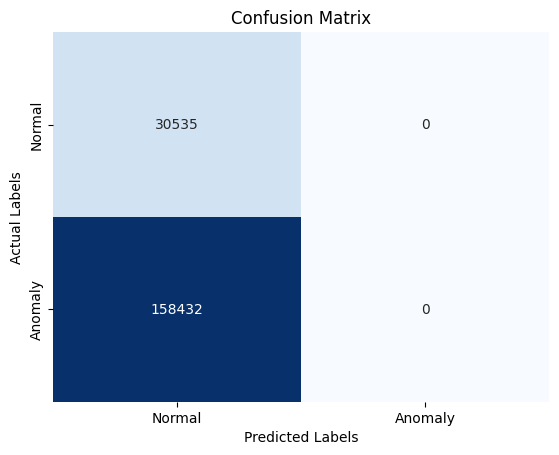

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust parameters as needed
model.fit(train_dataset.X, train_dataset.y)  # Assuming train_dataset is initialized somewhere in your code

# Predict using the trained Random Forest Classifier on the test dataset
pred = model.predict(test_dataset.X)

# Map predictions to binary labels (0: Normal, 1: Anomaly)
mapped = [1 if pred == 1 else 0 for pred in pred]

# Evaluate on the test set
print("\nTest Report:")
print(classification_report(test_dataset.y, mapped))

# Create a confusion matrix
conf_matrix = confusion_matrix(test_dataset.y, mapped)

# Plot the confusion matrix as a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()
